# ***Load libraries***

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,power_transform,OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,ConfusionMatrixDisplay,f1_score,roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [2]:
df = pd.read_csv('train.csv')
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [3]:
df.shape

(800, 22)

In [4]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [6]:
df.drop(["ID","age_desc"],axis=1,inplace=True)

In [7]:
df["age"] = df["age"].astype(int)

In [8]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


In [9]:
df.describe(include='object')

,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation
count,800,800,800,800,800,800,800
unique,2,12,2,2,56,2,6
top,m,White-European,no,no,United States,no,Self
freq,530,257,615,669,134,750,709


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()/df.shape[0]*100

,0
A1_Score,0.0
A2_Score,0.0
A3_Score,0.0
A4_Score,0.0
A5_Score,0.0
A6_Score,0.0
A7_Score,0.0
A8_Score,0.0
A9_Score,0.0
A10_Score,0.0


In [12]:
df['contry_of_res'].nunique()

56

In [13]:
df['relation'].value_counts()

,count
relation,
Self,709
?,40
Parent,29
Relative,18
Others,2
Health care professional,2


In [14]:
num_df = df.select_dtypes(include = "number")
cat_df = df.select_dtypes(include = "object")

In [15]:
num_df.corr()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
A1_Score,1.000000,0.401419,0.493016,0.383718,0.432912,0.371917,0.447262,0.191815,0.439397,0.390478,0.056050,0.307919,0.300474
A2_Score,0.401419,1.000000,0.489330,0.488173,0.427895,0.447721,0.452713,0.302040,0.511547,0.454422,0.083082,0.339144,0.372740
A3_Score,0.493016,0.489330,1.000000,0.558896,0.579769,0.511669,0.559118,0.315882,0.597022,0.510276,0.110244,0.428870,0.460927
A4_Score,0.383718,0.488173,0.558896,1.000000,0.559748,0.563543,0.554838,0.360781,0.576723,0.506292,0.102915,0.418214,0.501046
A5_Score,0.432912,0.427895,0.579769,0.559748,1.000000,0.494944,0.550663,0.292747,0.524624,0.436010,0.096118,0.369226,0.461773
A6_Score,0.371917,0.447721,0.511669,0.563543,0.494944,1.000000,0.496588,0.333694,0.536666,0.419172,0.058929,0.411550,0.543010
A7_Score,0.447262,0.452713,0.559118,0.554838,0.550663,0.496588,1.000000,0.271903,0.539433,0.455326,0.103069,0.401655,0.452338
A8_Score,0.191815,0.302040,0.315882,0.360781,0.292747,0.333694,0.271903,1.000000,0.352747,0.250438,0.015590,0.277795,0.312388
A9_Score,0.439397,0.511547,0.597022,0.576723,0.524624,0.536666,0.539433,0.352747,1.000000,0.485983,0.125676,0.377139,0.463347
A10_Score,0.390478,0.454422,0.510276,0.506292,0.436010,0.419172,0.455326,0.250438,0.485983,1.000000,0.107786,0.333650,0.343736


In [16]:
num_df.cov()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
A1_Score,0.246708,0.099574,0.121902,0.093967,0.105181,0.085006,0.108786,0.047660,0.109186,0.094318,0.454618,0.735297,0.059875
A2_Score,0.099574,0.249412,0.121652,0.120200,0.104531,0.102891,0.110713,0.075457,0.127810,0.110363,0.677559,0.814287,0.074681
A3_Score,0.121902,0.121652,0.247810,0.137171,0.141176,0.117209,0.136295,0.078661,0.148686,0.123529,0.896183,1.026407,0.092053
A4_Score,0.093967,0.120200,0.137171,0.243079,0.134994,0.127854,0.133955,0.088980,0.142253,0.121389,0.828579,0.991306,0.099105
A5_Score,0.105181,0.104531,0.141176,0.134994,0.239274,0.111408,0.131902,0.071633,0.128385,0.103717,0.767778,0.868310,0.090620
A6_Score,0.085006,0.102891,0.117209,0.127854,0.111408,0.211751,0.111899,0.076813,0.123548,0.093802,0.442814,0.910479,0.100246
A7_Score,0.108786,0.110713,0.136295,0.133955,0.131902,0.111899,0.239793,0.066605,0.132153,0.108429,0.824190,0.945598,0.088864
A8_Score,0.047660,0.075457,0.078661,0.088980,0.071633,0.076813,0.066605,0.250236,0.088279,0.060923,0.127351,0.668089,0.062692
A9_Score,0.109186,0.127810,0.148686,0.142253,0.128385,0.123548,0.132153,0.088279,0.250288,0.118235,1.026727,0.907104,0.092997
A10_Score,0.094318,0.110363,0.123529,0.121389,0.103717,0.093802,0.108429,0.060923,0.118235,0.236489,0.855954,0.780067,0.067062


In [17]:
num_df.skew()

,0
A1_Score,-0.242201
A2_Score,-0.120443
A3_Score,0.201385
A4_Score,0.345671
A5_Score,0.430386
A6_Score,0.855095
A7_Score,0.419684
A8_Score,-0.035071
A9_Score,0.020039
A10_Score,-0.484450


In [18]:
(df == 0).sum()

,0
A1_Score,352
A2_Score,376
A3_Score,440
A4_Score,468
A5_Score,484
A6_Score,557
A7_Score,482
A8_Score,393
A9_Score,404
A10_Score,306


In [19]:
df.nunique()

,0
A1_Score,2
A2_Score,2
A3_Score,2
A4_Score,2
A5_Score,2
A6_Score,2
A7_Score,2
A8_Score,2
A9_Score,2
A10_Score,2


In [20]:
num_df.quantile([0.25, 0.5, 0.75, 0.9, 0.99])

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.00,5.306575,0.0
0.50,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,24.00,9.605299,0.0
0.75,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,35.25,12.514484,0.0
0.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,51.00,13.894402,1.0
0.99,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,79.00,15.426351,1.0


# ***Data Visualization***

<Axes: >

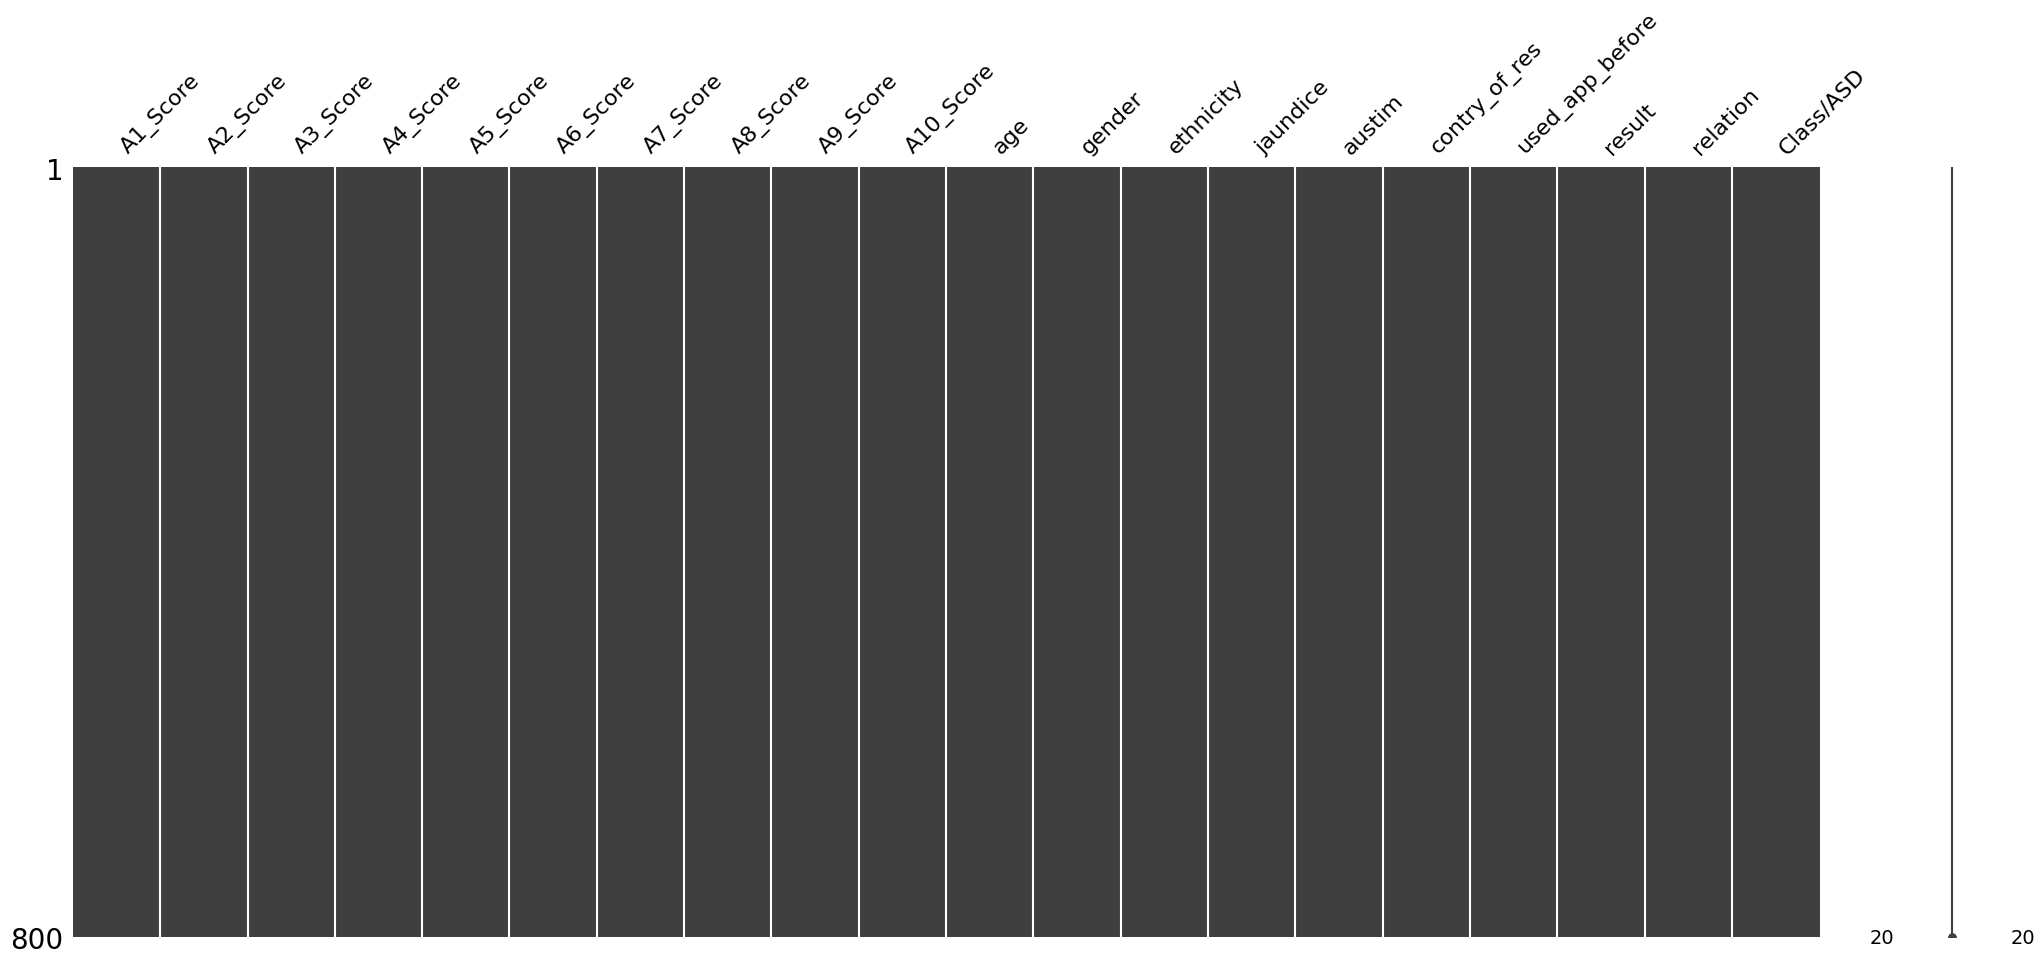

In [21]:
import missingno as msno
msno.matrix(df)


<Axes: >

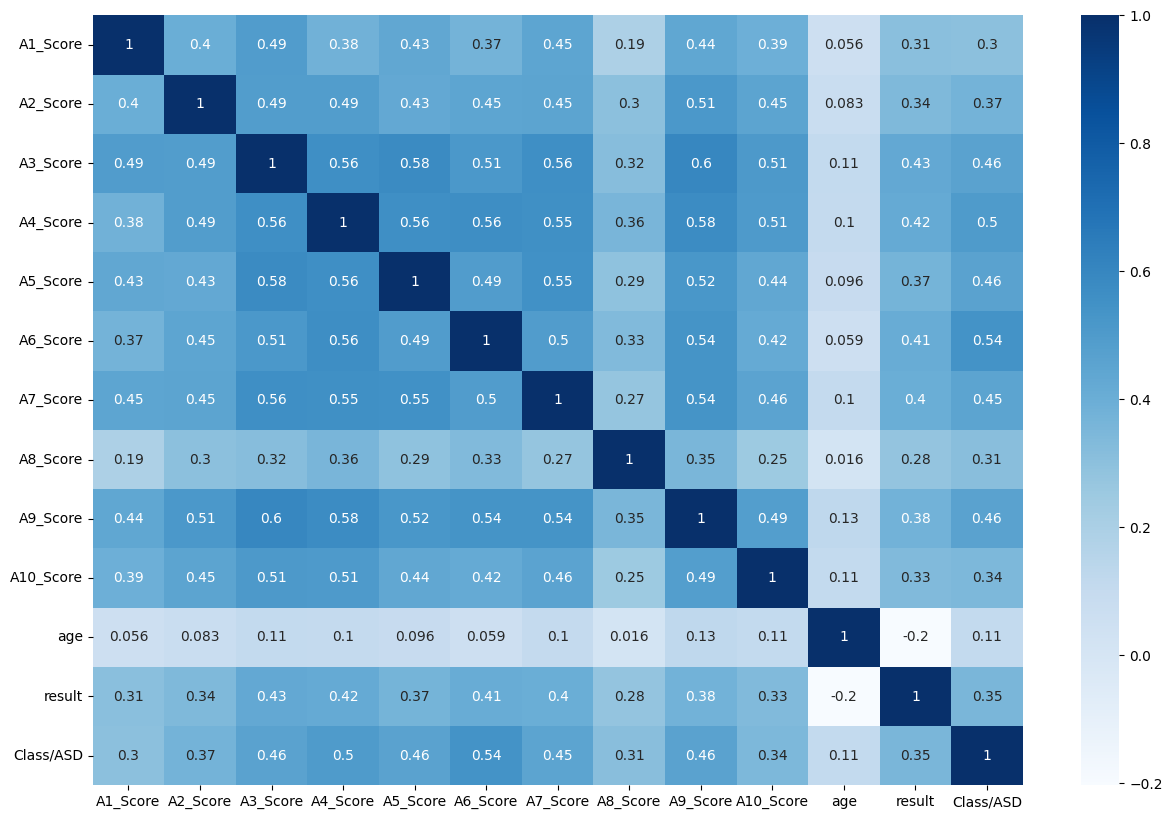

In [22]:
plt.figure(figsize=(15,10))
sns.heatmap(num_df.corr(), annot=True, cmap='Blues')

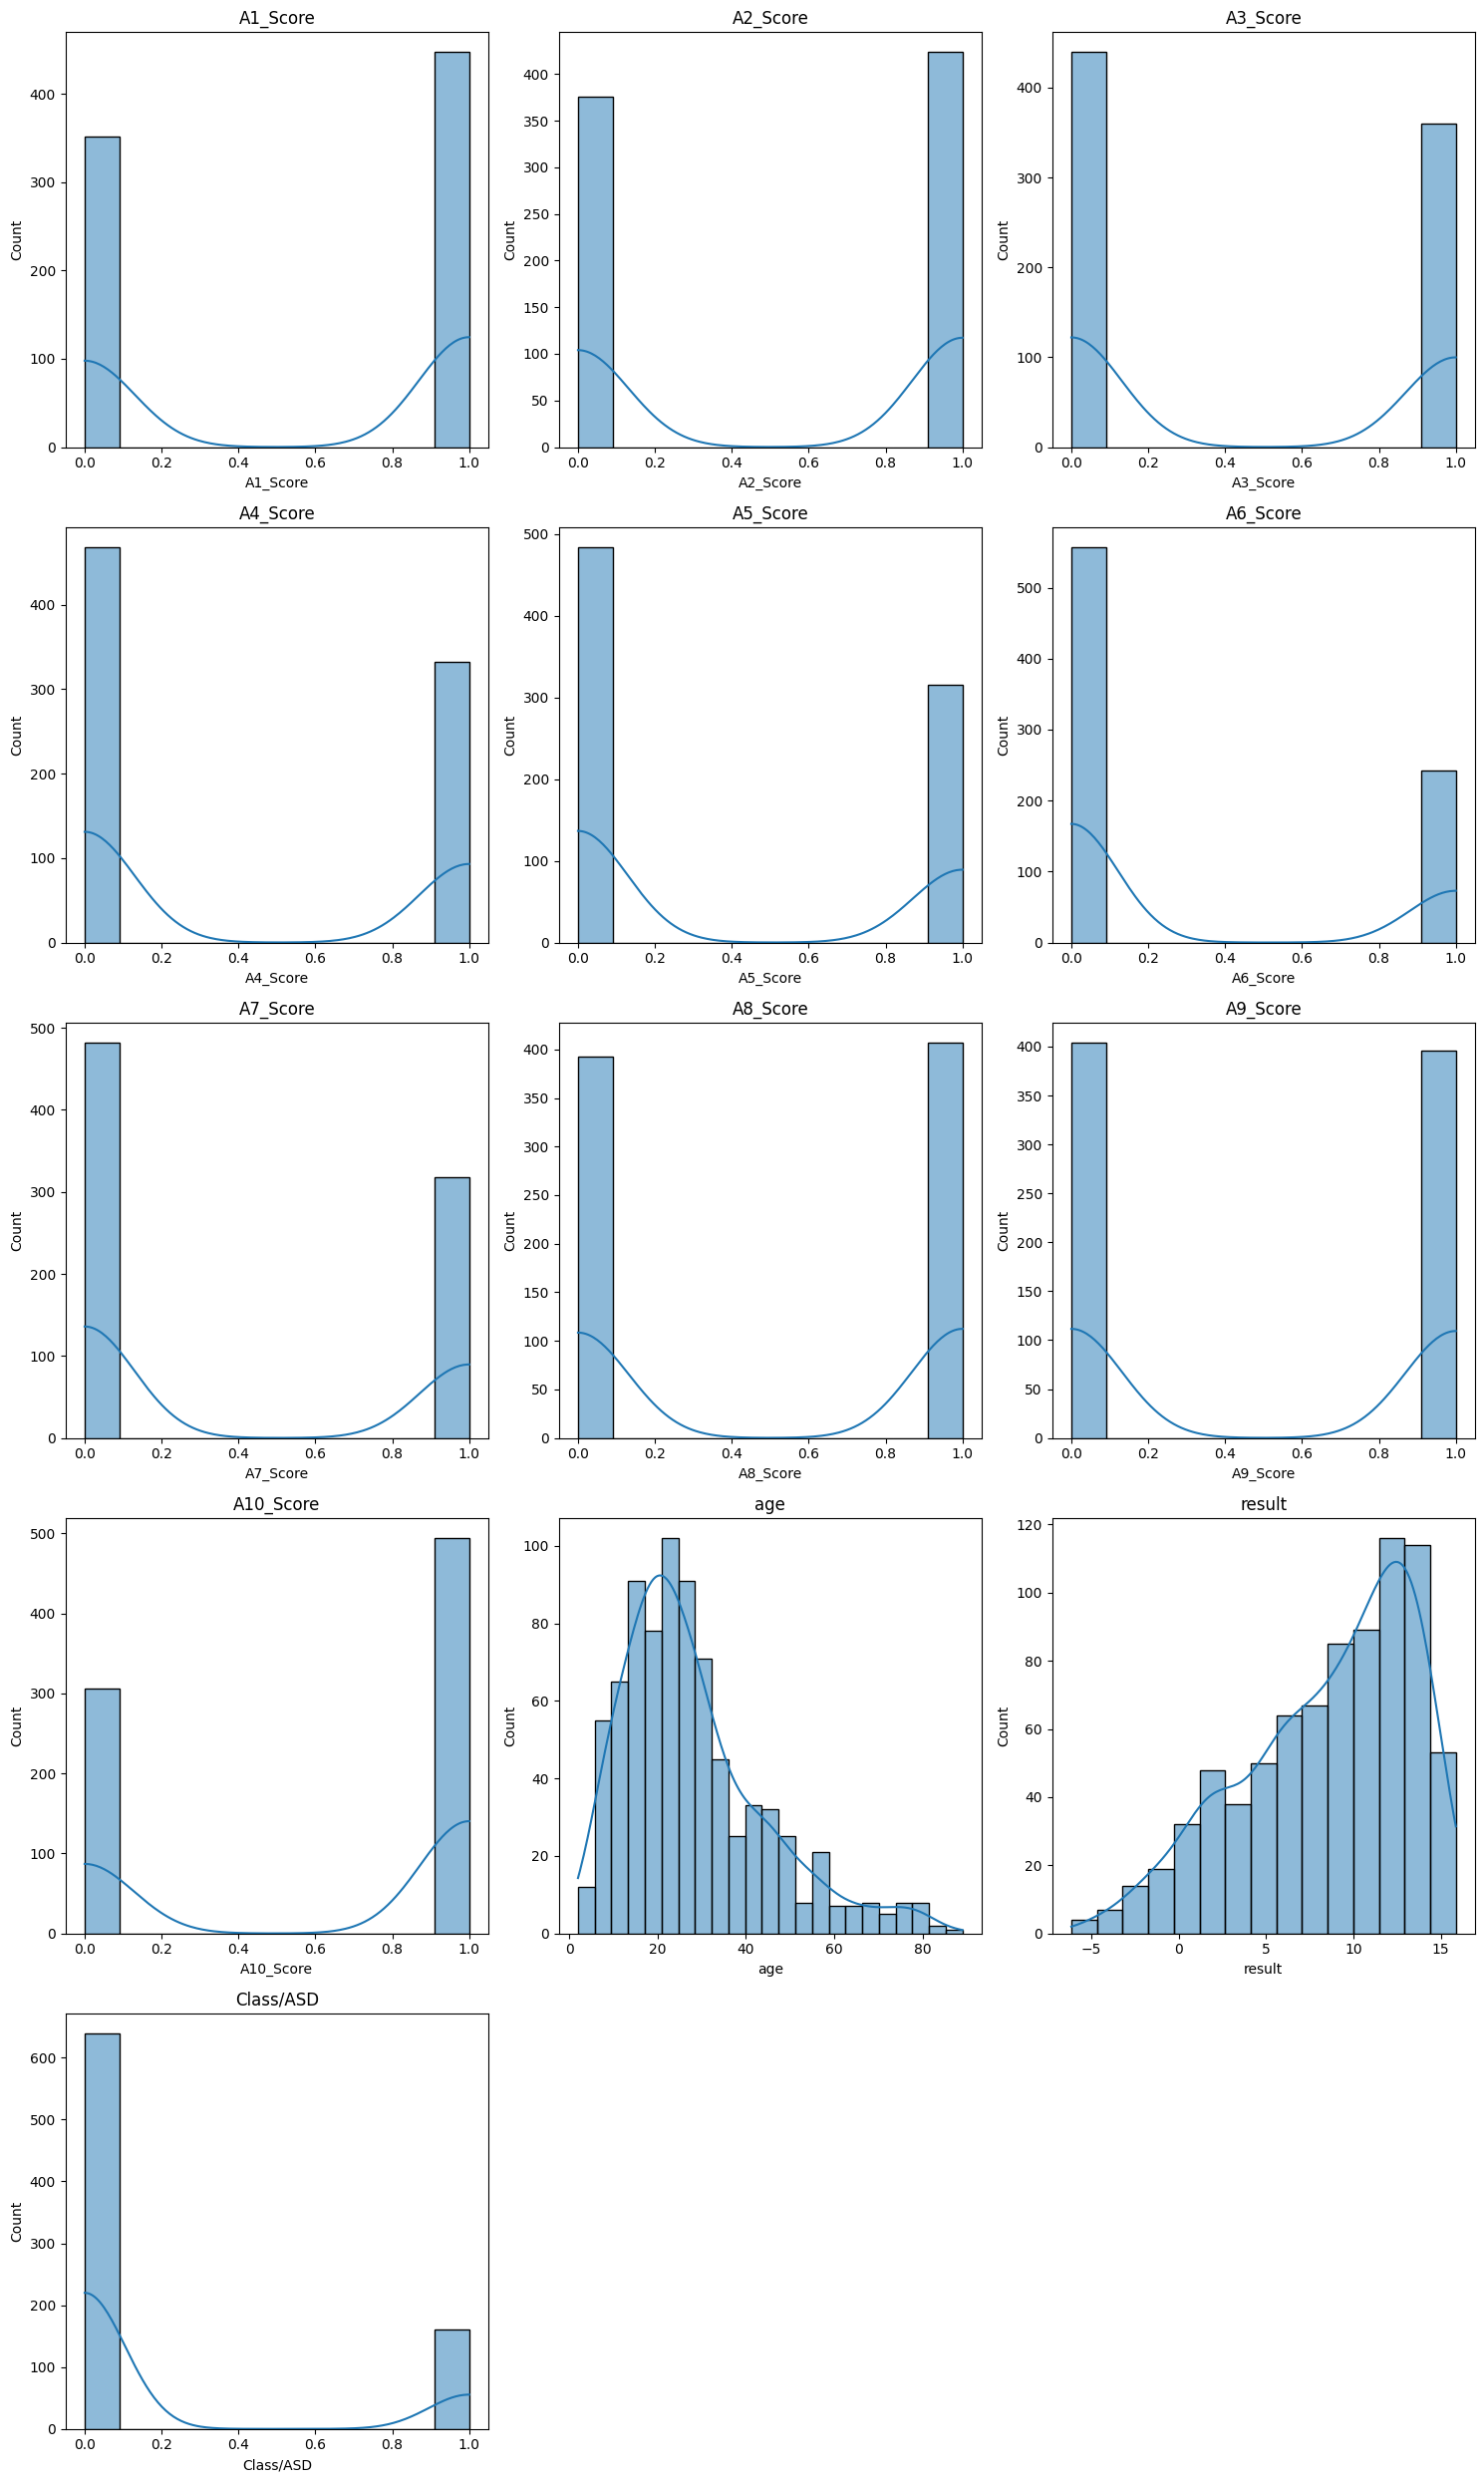

In [23]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

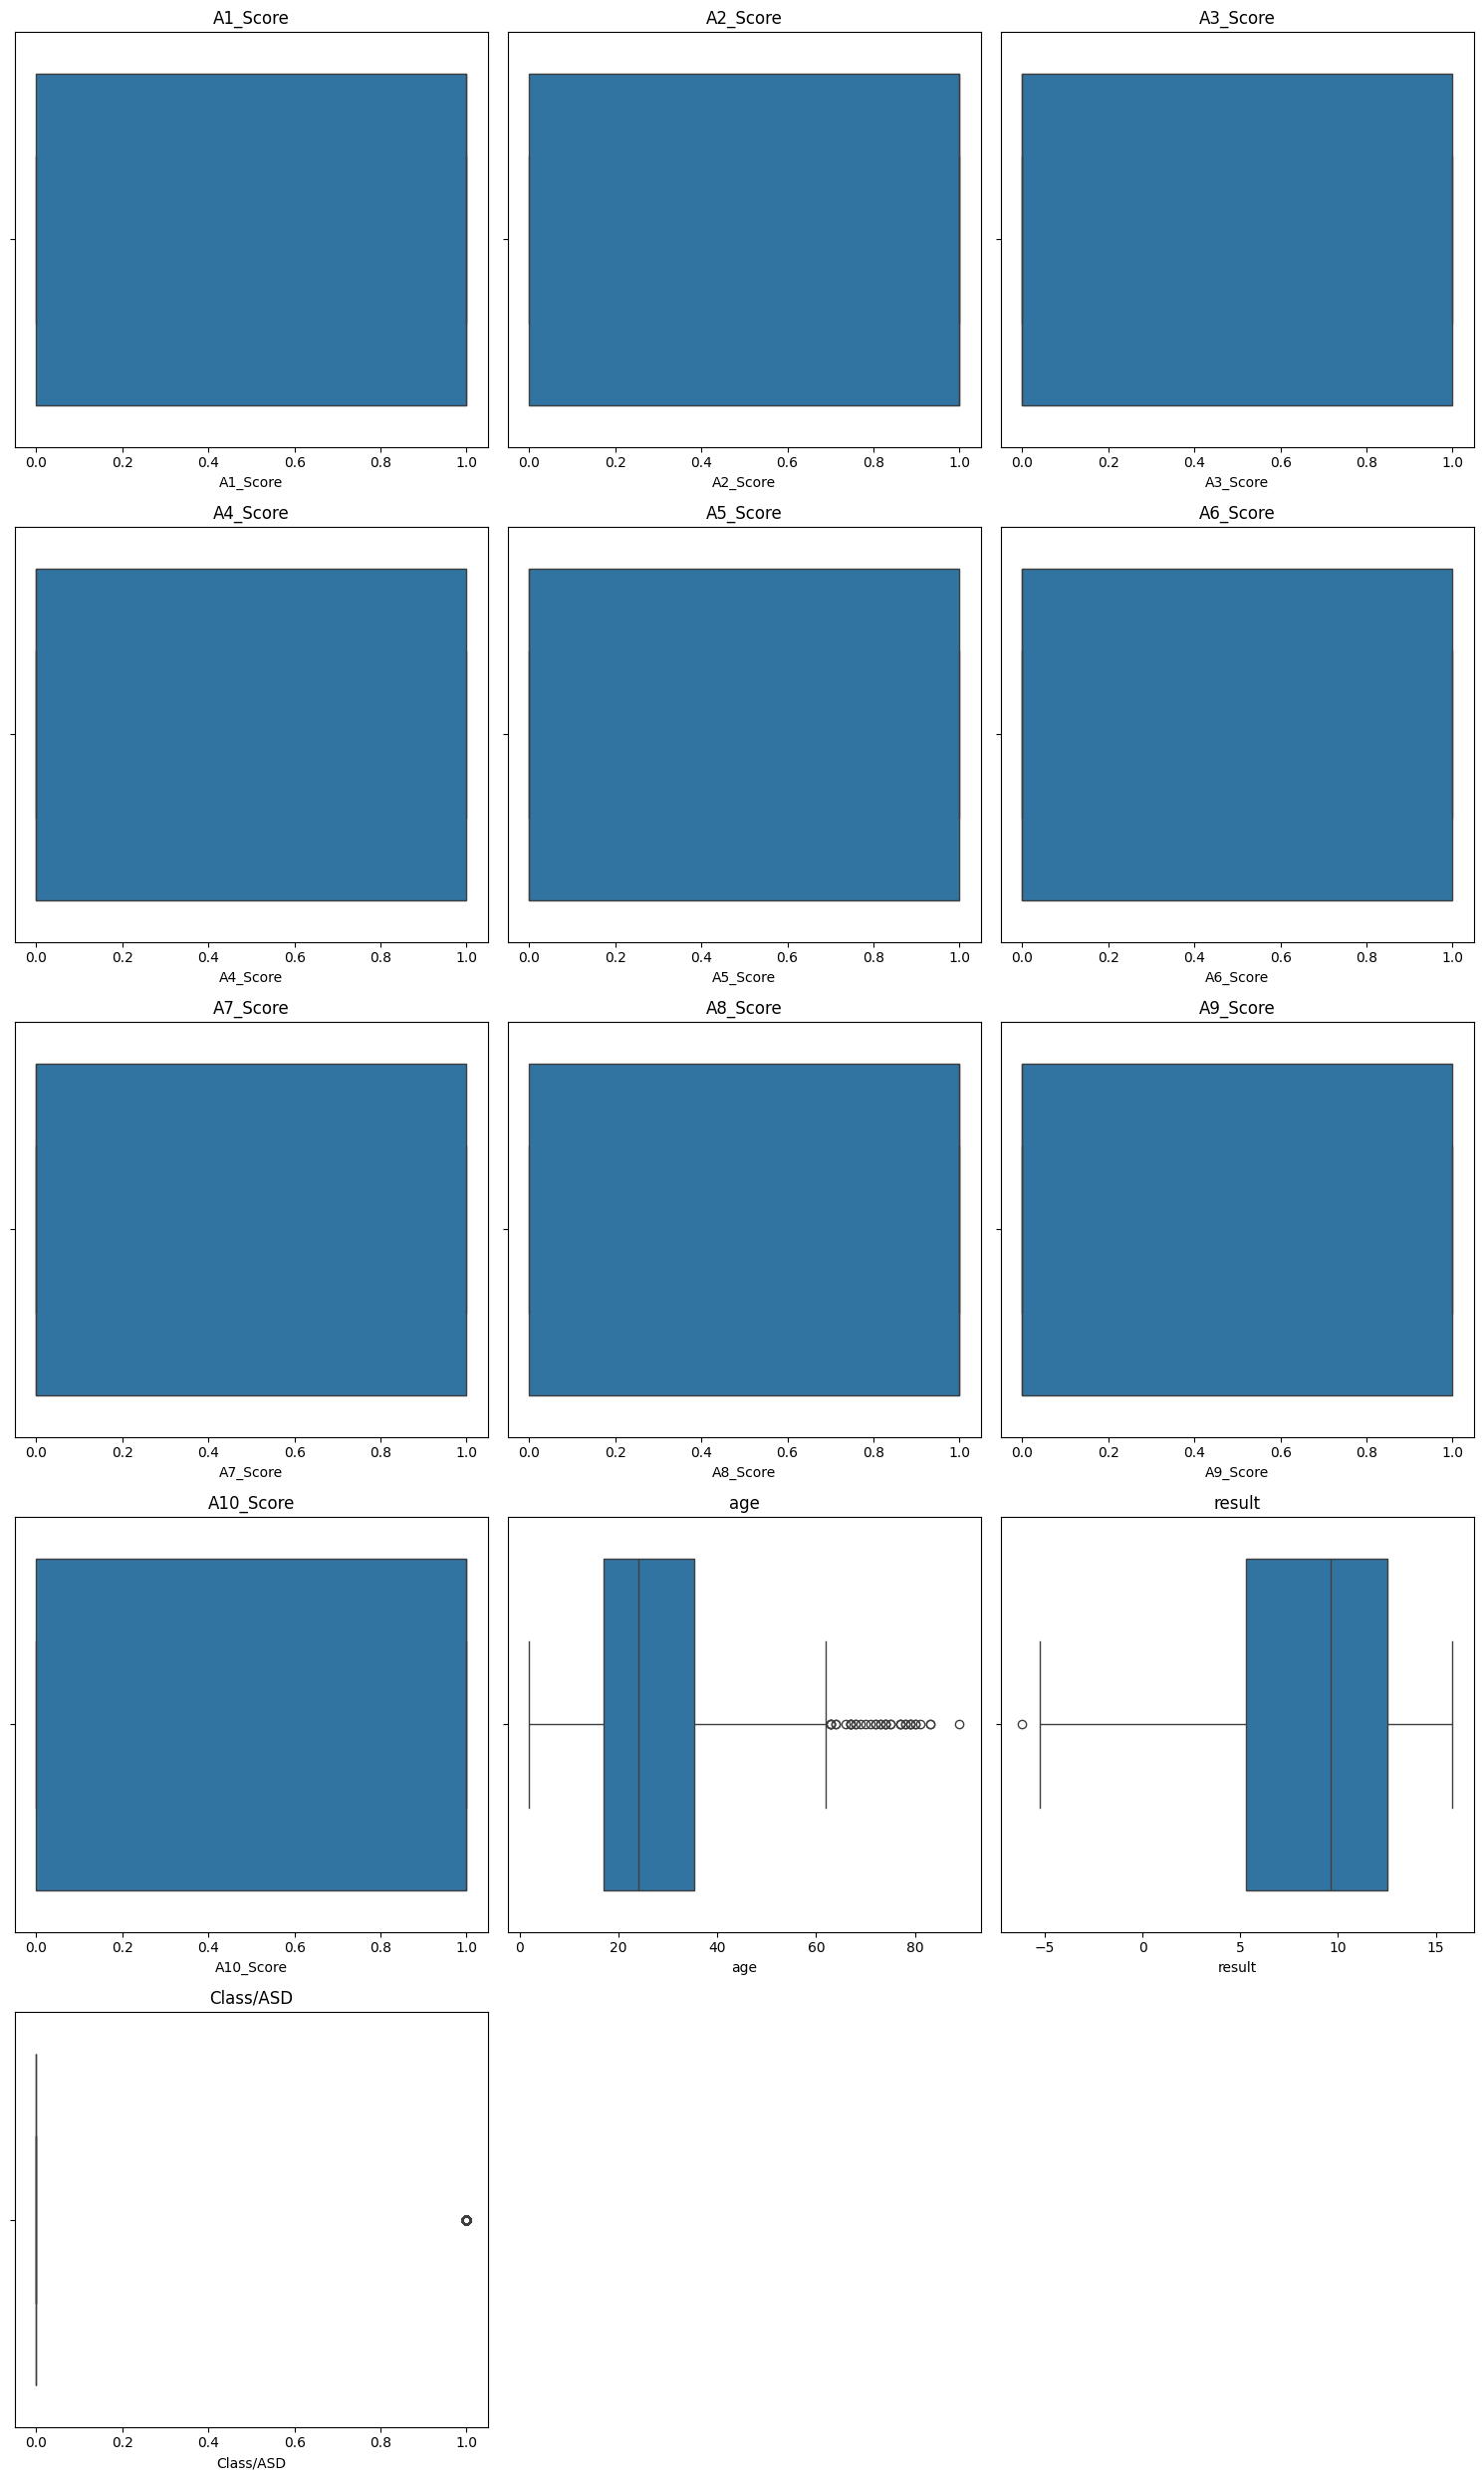

In [24]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

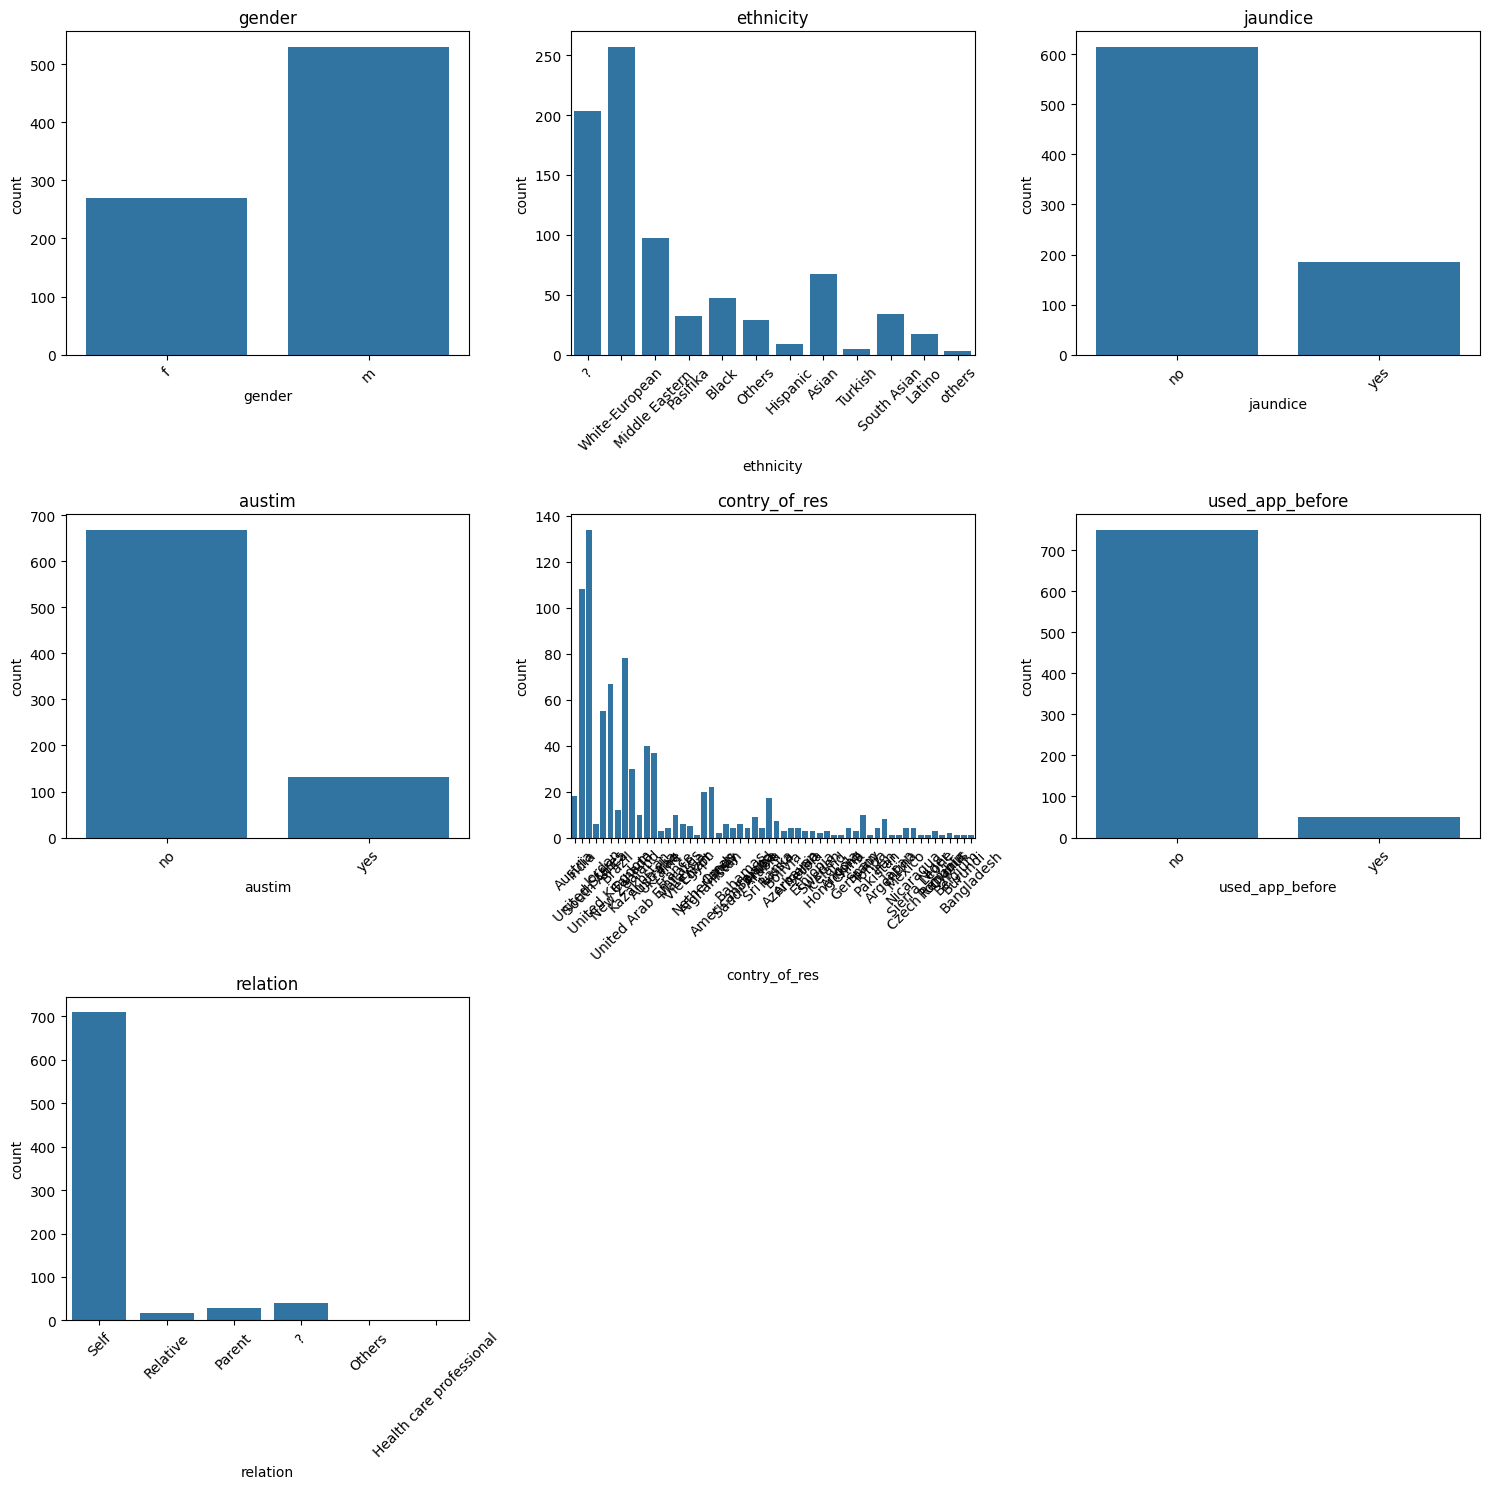

In [25]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [26]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)


In [27]:
(df == "?").sum()

,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


In [28]:
df["ethnicity"].replace("?", "unknown", inplace=True)
df["relation"].replace("?", "unknown", inplace=True)

In [42]:
encoder = LabelEncoder()
for col in cat_df:
    df[col] = encoder.fit_transform(df[col])

In [43]:
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

In [45]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2,random_state=42)

print(y.value_counts())
print(y_resampled.value_counts())

Class/ASD
0    639
1    161
Name: count, dtype: int64
Class/ASD
0    639
1    639
Name: count, dtype: int64


In [46]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [62]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [100,200],
            'max_depth': [None,10,20]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "SVC": (
        SVC(probability=True),
        {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    ),

    "LightGBM": (
        LGBMClassifier(verbose=-1),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(silent=True),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [67]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Best Params": best_params,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
    })

Training KNN...
Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training AdaBoost...
Training ExtraTrees...
Training XGBoost...
Training SVC...
Training LightGBM...
Training CatBoost...


In [81]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",1.000000,0.843750,0.782609,0.961832,0.863014,0.935420
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.998043,0.902344,0.868056,0.954198,0.909091,0.927023
2,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 200}",1.000000,0.898438,0.867133,0.946565,0.905109,0.934107
3,CatBoost,"{'depth': 6, 'iterations': 200, 'learning_rate...",0.997065,0.902344,0.873239,0.946565,0.908425,0.942107
4,RandomForest,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",0.939335,0.882812,0.848276,0.938931,0.891304,0.943389
5,ExtraTrees,"{'max_depth': 20, 'n_estimators': 100}",0.998043,0.890625,0.860140,0.938931,0.897810,0.950656
6,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 200}",0.983366,0.890625,0.865248,0.931298,0.897059,0.932092
7,SVC,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.966732,0.902344,0.895522,0.916031,0.905660,0.959023
8,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",0.890411,0.820312,0.785235,0.893130,0.835714,0.857374
9,LogisticRegression,{'C': 1},0.860078,0.796875,0.780142,0.839695,0.808824,0.879695


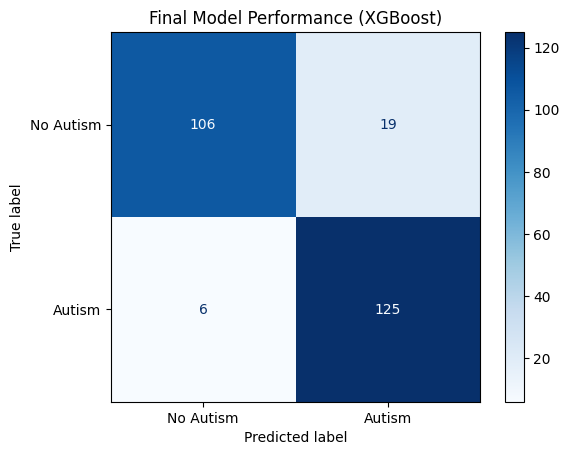

In [78]:
final_model = XGBClassifier(learning_rate= 0.1,max_depth=6,n_estimators= 200)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Autism', 'Autism'])
disp.plot(cmap='Blues')
plt.title('Final Model Performance (XGBoost)')
plt.show()

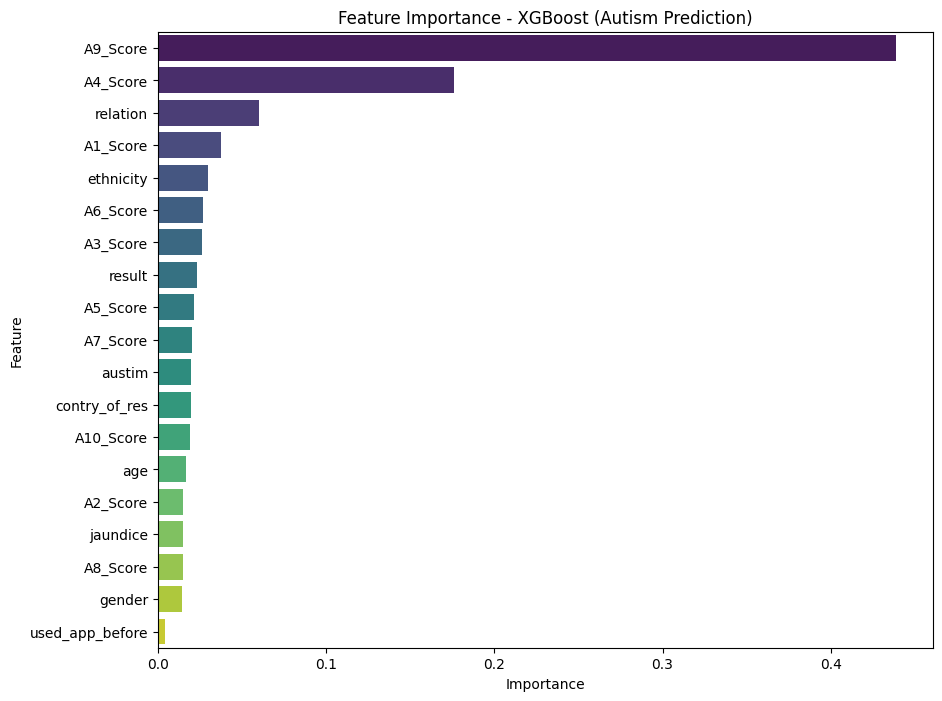

In [79]:
importances = final_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - XGBoost (Autism Prediction)')
plt.show()

In [76]:
feature_importance_df

,Feature,Importance
8,A9_Score,0.438690
3,A4_Score,0.176231
18,relation,0.060266
0,A1_Score,0.037377
12,ethnicity,0.029836
5,A6_Score,0.026796
2,A3_Score,0.026115
17,result,0.023264
4,A5_Score,0.021398
6,A7_Score,0.020277
